# Fig1: Acc as a function of training steps

In [247]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.patches as patches
data_root = Path("/Users/jliu/workspace/ICL/interp/uniform_1000_L3_M3/clm_noshuffle_seedbalanced/layer")

In [295]:
def load_data(data_path)->pd.DataFrame:
    df = pd.read_parquet(data_path)
    print(f"Row num: {df.shape[0]}")
    return df


def plot_shot(df,model_type,task_type):

    # --- Step 1. Group by checkpoint & context_size ---
    grouped = (
        df.groupby(['checkpoint_step', 'context_size'])['accuracy']
        .agg(['mean', 'std', 'count'])
        .reset_index()
    )
    grouped['sem'] = grouped['std'] / np.sqrt(grouped['count'])

    # --- Step 2. Sort checkpoints & split into 4 groups ---
    unique_ckpts = sorted(grouped['checkpoint_step'].unique())
    num_groups = 4
    ckpt_groups = np.array_split(unique_ckpts, num_groups)
    stage_labels = [f"Stage {i+1}" for i in range(num_groups)]

    # --- Step 3. Use 4 highly distinct colors ---
    stage_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  
    # blue, orange, green, red → very distinguishable

    # --- Step 4. Plot figure ---
    plt.figure(figsize=(12, 7))

    for stage_idx, (stage_ckpts, color) in enumerate(zip(ckpt_groups, stage_colors)):
        stage_df = grouped[grouped['checkpoint_step'].isin(stage_ckpts)]
        
        # Average across checkpoints in this stage
        stage_avg = (
            stage_df.groupby('context_size')
                    .agg(mean=('mean', 'mean'), sem=('sem', 'mean'))
                    .reset_index()
        )
        
        # Plot stage line with SEM error bars
        plt.errorbar(
            stage_avg['context_size'],
            stage_avg['mean'],
            yerr=stage_avg['sem'],
            fmt='o-',
            color=color,
            label=stage_labels[stage_idx],
            capsize=4,
            elinewidth=1.3,
            linewidth=2.3,
            markersize=6,
            alpha=0.95
        )

    # --- Step 5. Beautify plot ---
    plt.xlabel('Context Size (Shots)', fontsize=13)
    plt.ylabel('Mean Num Correct', fontsize=13)
    plt.title(f"{model_type}_{task_type}", fontsize=15)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(title="Training Stage", fontsize=10)
    plt.tight_layout()
    plt.show()




def plot_steps(df, task_type,target_shot=None):
    # --- Step 1. Group by checkpoint only ---

    if target_shot:
        df = df[df['context_size']==target_shot]

    grouped = (
        df.groupby('checkpoint_step')['accuracy']
        .agg(['mean', 'std', 'count'])
        .reset_index()
    )
    grouped['sem'] = grouped['std'] / np.sqrt(grouped['count'])

    # --- Step 2. Plot figure ---
    #plt.figure(figsize=(12, 7))
    plt.errorbar(
        grouped['checkpoint_step'],
        grouped['mean'],
        yerr=grouped['sem'],
        fmt='o-',
        capsize=4,
        elinewidth=1.3,
        linewidth=2.3,
        markersize=6,
        alpha=0.95,
        label=task_type
    )

    # --- Step 3. Beautify plot ---
    plt.xlabel('Training Step (Checkpoint)', fontsize=13)
    plt.ylabel('Mean Accuracy', fontsize=13)
    plt.grid(True, linestyle='--', alpha=0.5)


In [293]:
import numpy as np
import matplotlib.pyplot as plt

def plot_steps(df, task_type, target_shot=None, sample_per_group=50):
    # --- Step 0: Filter by target shot if provided ---
    if target_shot:
        df = df[df['context_size'] == target_shot]

    # --- Step 1: Weighted sampling by accuracy per checkpoint ---
    def sample_points(group):
        # normalize accuracy to get probabilities
        probs = group['accuracy'] - group['accuracy'].min() + 1e-6  # avoid zeros
        probs /= probs.sum()
        # sample points (without replacement if group is smaller)
        n = min(sample_per_group, len(group))
        return group.sample(n=n, weights=probs, replace=False)

    sampled_df = df.groupby('checkpoint_step', group_keys=False).apply(sample_points)

    # --- Step 2: Compute mean, std, sem for plotting ---
    grouped = (
        sampled_df.groupby('checkpoint_step')['accuracy']
        .agg(['mean', 'std', 'count'])
        .reset_index()
    )
    grouped['sem'] = grouped['std'] / np.sqrt(grouped['count'])

    # --- Step 3: Plot figure ---
    plt.errorbar(
        grouped['checkpoint_step'],
        grouped['mean'],
        yerr=grouped['sem'],
        fmt='o-',
        capsize=4,
        elinewidth=1.3,
        linewidth=2.3,
        markersize=6,
        alpha=0.95,
        label=task_type
    )

    # --- Step 4: Beautify plot ---
    plt.xlabel('Training Step (Checkpoint)', fontsize=13)
    plt.ylabel('Mean Accuracy', fontsize=13)
    plt.grid(True, linestyle='--', alpha=0.5)


Row num: 72000
Row num: 72000
Row num: 72000
Row num: 11520


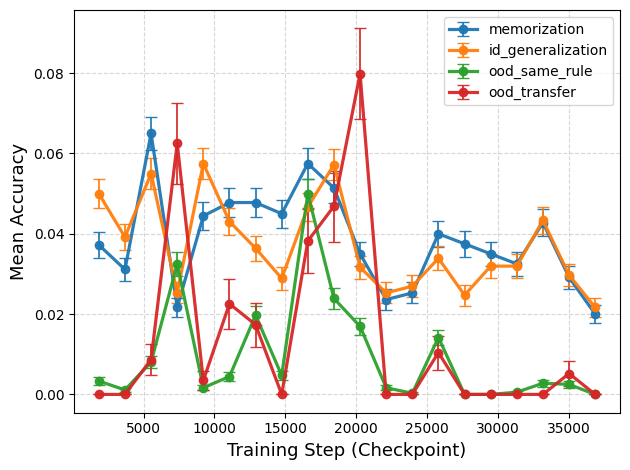

Row num: 72000
Row num: 72000
Row num: 11520
Row num: 11520


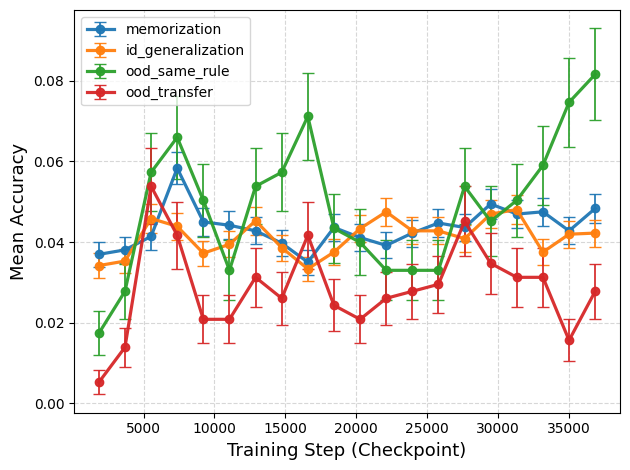

In [296]:
# Run pipeline first
prefix = Path("/Users/jliu/workspace/ICL/interp")
suffix = "noshuffle_seedbalanced/acc"
model_type_lst = ["clm","mlm"]
seed_lst = [1000]
eval_type_lst = ["memorization", "id_generalization", "ood_same_rule", "ood_transfer"]
spec_dict = {}
for model_type in model_type_lst:
    for seed in seed_lst:
        for eval_type in eval_type_lst:
            data_path = prefix / f"uniform_{seed}_L3_M3"/f"{model_type}_{suffix}"/f"{eval_type}.parquet"
            
            df = load_data(data_path)
            plot_steps(df, eval_type)
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.show()
   

# load data

In [ ]:
eval_type_lst = ["memorization", "id_generalization", "ood_same_rule", "ood_transfer"]

eval_type_lst = ["memorization", "id_generalization", "ood_same_rule"]
data_dir = Path(data_root/"id_generalization.json")

def compute_stat(stat):
    spec_dict = {}
    for eval_type in eval_type_lst:
        with open(data_root/f"{eval_type}.json", encoding="utf-8") as f:
            data = json.load(f)
            spec = data['36880'][stat]
        spec_dict[eval_type] = spec
    return spec_dict

# explore layer specialization

# PCA analysis

In [67]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
class ClusteringModule:
    """Cluster heads based on extracted attention features."""

    def __init__(self, n_clusters=4):
        self.n_clusters = n_clusters
        self.cluster_labels = None
        self.cluster_centers = None

    def run(self, features):
        # Use behavioral features only
        X = np.array([[f["entropy"], f["locality"], f["cross_attention"], f["query_to_context"]] for f in features])
        X_scaled = StandardScaler().fit_transform(X)

        kmeans = KMeans(n_clusters=self.n_clusters, random_state=42)
        self.cluster_labels = kmeans.fit_predict(X_scaled)
        self.cluster_centers = kmeans.cluster_centers_
        return self.cluster_labels, self.cluster_centers


In [179]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# ========================
# Phase-1: Cluster Selected Layers
# ========================
def cluster_selected_layers(all_features, scores, n_clusters=4, top_k_layers=1):
    """
    Cluster heads in top layers based on layer specialization scores.

    Args:
        all_features (list[dict]): Phase-1 features
        scores (dict): Layer specialization scores, e.g., {layer: score, ...}
        n_clusters (int): Number of clusters for KMeans
        top_k_layers (int): How many top layers to select

    Returns:
        result_dict: dict with selected_layers, cluster_labels, cluster_stats
        flattened_features: np.array of features used for clustering
        head_map: list of (seq_id, layer, head) corresponding to rows
    """
    # --- 1. Select top layers ---
    top_layers = sorted(scores, key=lambda l: scores[l], reverse=True)[:top_k_layers]
    top_layers = [int(x) for x in top_layers]
    print(f"Selected layers for clustering: {top_layers}")

    # --- 2. Filter features for selected layers ---
    features_to_cluster = [f for f in all_features if int(f["layer"]) in top_layers]

    # --- 3. Flatten features & map heads ---
    flattened_features = []
    head_map = []
    for f in features_to_cluster:
        feat_vec = [f["entropy"], f["locality"], f["cross_attention"], f["query_to_context"]]
        flattened_features.append(feat_vec)
        head_map.append((f["seq_id"], int(f["layer"]), f["head"]))

    flattened_features = np.array(flattened_features)

    # --- 4. Scale features ---
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(flattened_features)

    # --- 5. Run clustering ---
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels = kmeans.fit_predict(X_scaled)

    # --- 6. Map labels back to layers/heads ---
    cluster_labels = {layer: {} for layer in top_layers}
    for idx, (seq_id, layer, head_idx) in enumerate(head_map):
        cluster_labels[layer][head_idx] = int(labels[idx])

    # --- 7. Compute cluster stats ---
    cluster_stats = {}
    for layer in top_layers:
        layer_labels = cluster_labels[layer]
        stats = {}
        for label in range(n_clusters):
            assigned_heads = [h for h, l in layer_labels.items() if l == label]
            stats[label] = {"num_heads": len(assigned_heads)}
        cluster_stats[layer] = stats

    result_dict = {
        "selected_layers": top_layers,
        "cluster_labels": cluster_labels,
        "cluster_stats": cluster_stats,
    }

    return result_dict, flattened_features, head_map, scaler


# ========================
# Phase-2: Geometry Analysis (PCA)
# ========================
def run_pca(feature_matrix, n_components=2):
    """
    Reduce feature dimensionality using PCA.

    Args:
        feature_matrix (np.array): N x D array
        n_components (int): number of PCA components

    Returns:
        pca_features: N x n_components array
        pca_model: fitted PCA object
    """
    pca_model = PCA(n_components=n_components)
    pca_features = pca_model.fit_transform(feature_matrix)
    return pca_features, pca_model


# ========================
# Example pipeline usage
# ========================
def pipeline(all_features, layer_scores, n_clusters=3, top_k_layers=1, pca_components=2):
    """
    Full pipeline: select layers, cluster heads, scale features, and optionally run PCA.

    Returns:
        dict with clustering results and PCA features
    """
    # Phase-1: Cluster selected layers
    clustering_result, features_scaled, head_map, scaler = cluster_selected_layers(
        all_features, layer_scores, n_clusters=n_clusters, top_k_layers=top_k_layers
    )

    # Phase-2: PCA for geometry analysis
    pca_features, pca_model = run_pca(features_scaled, n_components=pca_components)

    pipeline_result = {
        "clustering": clustering_result,
        "features_scaled": features_scaled,
        "head_map": head_map,
        "scaler": scaler,
        "pca_features": pca_features,
        "pca_model": pca_model,
    }
    return pipeline_result

import matplotlib.pyplot as plt
import numpy as np

def plot_pipeline_results(pipeline_result, show_layer_shapes=True):
    """
    Visualize clustering and PCA results from the pipeline.

    Args:
        pipeline_result (dict): output from the pipeline()
        show_layer_shapes (bool): if True, use different markers per layer in PCA
    """
    clustering = pipeline_result["clustering"]
    selected_layers = clustering["selected_layers"]
    cluster_stats = clustering["cluster_stats"]
    cluster_labels = clustering["cluster_labels"]

    head_map = pipeline_result["head_map"]
    pca_features = pipeline_result["pca_features"]

    # --- 1. Bar plots: Number of heads per cluster per layer ---
    for layer in selected_layers:
        stats = cluster_stats[layer]
        clusters = list(stats.keys())
        counts = [stats[c]["num_heads"] for c in clusters]

        plt.figure()
        plt.bar(clusters, counts, color='skyblue')
        plt.xlabel("Cluster")
        plt.ylabel("Number of Heads")
        plt.title(f"Layer {layer} Head Clusters")
        plt.xticks(clusters)
        plt.show()

    # --- 2. PCA scatter plot ---
    # Get cluster label for each point
    labels_for_pca = []
    layers_for_pca = []
    for seq_id, layer, head_idx in head_map:
        labels_for_pca.append(cluster_labels[layer][head_idx])
        layers_for_pca.append(layer)
    labels_for_pca = np.array(labels_for_pca)
    layers_for_pca = np.array(layers_for_pca)

    plt.figure(figsize=(8,6))
    if show_layer_shapes:
        markers = ['o', 's', '^', 'v', 'P', '*', 'X', 'D']
        unique_layers = np.unique(layers_for_pca)
        for i, layer in enumerate(unique_layers):
            mask = layers_for_pca == layer
            plt.scatter(
                pca_features[mask,0], pca_features[mask,1],
                c=labels_for_pca[mask],
                cmap='tab10',
                marker=markers[i % len(markers)],
                alpha=0.7,
                label=f'Layer {layer}'
            )
        plt.legend(title="Layer")
    else:
        plt.scatter(pca_features[:,0], pca_features[:,1],
                    c=labels_for_pca, cmap='tab10', alpha=0.7)
        plt.colorbar(label="Cluster")

    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.title("PCA of Head Features Colored by Cluster")
    plt.show()


In [114]:
import matplotlib.pyplot as plt
import numpy as np

def plot_pipeline_results_annotated(pipeline_result, show_layer_shapes=True, annotate=False):
    """
    Visualize clustering and PCA results with optional annotations.

    Args:
        pipeline_result (dict): output from pipeline()
        show_layer_shapes (bool): if True, use different markers per layer in PCA
        annotate (bool): if True, annotate points with head index or entropy
    """
    clustering = pipeline_result["clustering"]
    selected_layers = clustering["selected_layers"]
    cluster_stats = clustering["cluster_stats"]
    cluster_labels = clustering["cluster_labels"]

    head_map = pipeline_result["head_map"]
    pca_features = pipeline_result["pca_features"]
    features_scaled = pipeline_result["features_scaled"]

    # --- 1. Bar plots: Number of heads per cluster per layer ---
    for layer in selected_layers:
        stats = cluster_stats[layer]
        clusters = list(stats.keys())
        counts = [stats[c]["num_heads"] for c in clusters]

        plt.figure()
        plt.bar(clusters, counts, color='skyblue')
        plt.xlabel("Cluster")
        plt.ylabel("Number of Heads")
        plt.title(f"Layer {layer} Head Clusters")
        plt.xticks(clusters)
        plt.show()

    # --- 2. PCA scatter plot ---
    labels_for_pca = []
    layers_for_pca = []
    for seq_id, layer, head_idx in head_map:
        labels_for_pca.append(cluster_labels[layer][head_idx])
        layers_for_pca.append(layer)
    labels_for_pca = np.array(labels_for_pca)
    layers_for_pca = np.array(layers_for_pca)

    plt.figure(figsize=(10,7))
    if show_layer_shapes:
        markers = ['o', 's', '^', 'v', 'P', '*', 'X', 'D']
        unique_layers = np.unique(layers_for_pca)
        for i, layer in enumerate(unique_layers):
            mask = layers_for_pca == layer
            sc = plt.scatter(
                pca_features[mask,0], pca_features[mask,1],
                c=labels_for_pca[mask],
                cmap='tab10',
                marker=markers[i % len(markers)],
                alpha=0.7,
                label=f'Layer {layer}'
            )
            if annotate:
                for idx in np.where(mask)[0]:
                    plt.text(
                        pca_features[idx,0]+0.02, pca_features[idx,1]+0.02,
                        f"H{head_map[idx][2]}", fontsize=8
                    )
        plt.legend(title="Layer")
    else:
        sc = plt.scatter(pca_features[:,0], pca_features[:,1],
                         c=labels_for_pca, cmap='tab10', alpha=0.7)
        if annotate:
            for idx in range(len(pca_features)):
                plt.text(
                    pca_features[idx,0]+0.02, pca_features[idx,1]+0.02,
                    f"H{head_map[idx][2]}", fontsize=8
                )
        plt.colorbar(sc, label="Cluster")

    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.title("PCA of Head Features Colored by Cluster")
    plt.show()


In [178]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

def plot_pipeline_results_colored(pipeline_result, show_layer_shapes=True, annotate=False):
    clustering = pipeline_result["clustering"]
    selected_layers = clustering["selected_layers"]
    cluster_stats = clustering["cluster_stats"]
    cluster_labels = clustering["cluster_labels"]

    head_map = pipeline_result["head_map"]
    pca_features = pipeline_result["pca_features"]

    # --- 1. Bar plots (same as before) ---
    for layer in selected_layers:
        stats = cluster_stats[layer]
        clusters = list(stats.keys())
        counts = [stats[c]["num_heads"] for c in clusters]

        plt.figure()
        plt.bar(clusters, counts, color='skyblue')
        plt.xlabel("Cluster")
        plt.ylabel("Number of Heads")
        plt.title(f"Layer {layer} Head Clusters")
        plt.xticks(clusters)
        plt.show()

    # --- 2. PCA scatter with different colors per (layer, cluster) ---
    labels_for_pca = []
    layers_for_pca = []
    for seq_id, layer, head_idx in head_map:
        labels_for_pca.append(cluster_labels[layer][head_idx])
        layers_for_pca.append(layer)
    labels_for_pca = np.array(labels_for_pca)
    layers_for_pca = np.array(layers_for_pca)

    plt.figure(figsize=(10,7))

    # Define distinct colors for each (layer, cluster) combination
    unique_pairs = sorted(set(zip(layers_for_pca, labels_for_pca)))
    n_colors = len(unique_pairs)
    color_map = plt.cm.get_cmap('tab20', n_colors)
    pair_to_color = {pair: color_map(i) for i, pair in enumerate(unique_pairs)}

    markers = ['o', 's', '^', 'v', 'P', '*', 'X', 'D']

    for i, (layer, cluster) in enumerate(unique_pairs):
        mask = (layers_for_pca == layer) & (labels_for_pca == cluster)
        plt.scatter(
            pca_features[mask,0], pca_features[mask,1],
            color=pair_to_color[(layer, cluster)],
            marker=markers[layer % len(markers)] if show_layer_shapes else 'o',
            alpha=0.8,
            label=f"L{layer}-C{cluster}"
        )
        if annotate:
            for idx in np.where(mask)[0]:
                plt.text(
                    pca_features[idx,0]+0.02, pca_features[idx,1]+0.02,
                    f"H{head_map[idx][2]}", fontsize=8
                )

    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.title("PCA of Head Features Colored by Layer-Cluster")
    plt.legend(title="Layer-Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


In [215]:
def run_pipeline(data_root,eval_type, n_clusters=2,plot=False):
    with open(data_root/f"{eval_type}.json", encoding="utf-8") as f:
            data = json.load(f)
    # loop over different steps
    for step, subdict in data.items():
        all_features = subdict["features"]
        layer_spec_scores = subdict["layer_spec"]
        
    pipeline_result = pipeline(all_features, layer_spec_scores, n_clusters=n_clusters)
    # Visualize with annotations
    if plot:
        plot_pipeline_results_annotated(pipeline_result, show_layer_shapes=True, annotate=False)
    return subdict["layer_spec"]

In [219]:
def run_pipeline(data_root,eval_type, n_clusters=2,plot=False):
    with open(data_root/f"{eval_type}.json", encoding="utf-8") as f:
            data = json.load(f)
    # loop over different steps
    spec_dict = {}
    for step, subdict in data.items():
        all_features = subdict["features"]
        layer_spec_scores = subdict["layer_spec"]
        spec_dict[step] = layer_spec_scores
    pipeline_result = pipeline(all_features, layer_spec_scores, n_clusters=n_clusters)
    # Visualize with annotations
    if plot:
        plot_pipeline_results_colored(pipeline_result, show_layer_shapes=True, annotate=False)
    return spec_dict

In [ ]:
eval_type_lst = ["memorization", "id_generalization", "ood_same_rule", "ood_transfer"]

def compute_stat(stat):
    spec_dict = {}
    for eval_type in eval_type_lst:
        with open(data_root/f"{eval_type}.json", encoding="utf-8") as f:
            data = json.load(f)
            spec = data['36880'][stat]
        spec_dict[eval_type] = spec
    return spec_dict

# checklist
1000
    clm: ood_transfer
    mlm: ood_transfer, ood_same_rule

500
    clm: "memorization", "id_generalization", "ood_same_rule", "ood_transfer"
    mlm: ood_transfer, ood_same_rule

1500
    clm: id, ood_same_rule,ood_transfer
    mlm: id, ood_same_rule,ood_transfer

In [ ]:
# Run pipeline first
prefix = Path("/Users/jliu/workspace/ICL/interp")
suffix = "noshuffle_seedbalanced/layer"
model_type = "clm"
seed_lst = [500, 1000, 1500]
eval_type_lst = ["memorization", "id_generalization", "ood_same_rule", "ood_transfer"]
spec_dict = {}
for seed in seed_lst:
    data_root = prefix / f"uniform_{seed}_L3_M3"/f"{model_type}_{suffix}"
    spec_dict[seed] = {}
    for eval_type in eval_type_lst:
        try:
            spec_dict[seed][eval_type] = run_pipeline(data_root,eval_type, n_clusters=2,plot=False)
        except:
            pass

Selected layers for clustering: [1]
Selected layers for clustering: [1]
Selected layers for clustering: [1]
Selected layers for clustering: [0]
Selected layers for clustering: [2]
Selected layers for clustering: [2]


In [220]:
run_pipeline(data_root,"memorization", n_clusters=2,plot=False)

Selected layers for clustering: [2]


{'2766': {'0': 0.05129400404280763,
  '1': 0.004807510010702561,
  '2': 0.008722978094881883,
  '3': 0.03681363850706061,
  '4': 0.0760086591042679,
  '5': 0.006508664567693166},
 '5532': {'0': 0.12679261748961693,
  '1': 0.28334979601967847,
  '2': 0.01450780106734683,
  '3': 0.0025809452619060063,
  '4': 0.010148851927312146,
  '5': 0.05312617442948483},
 '8298': {'0': 0.09752918998465228,
  '1': 0.14908777020497652,
  '2': 0.08648552167845779,
  '3': 0.014010781844063526,
  '4': 0.004379309761444809,
  '5': 0.03539435033841399},
 '11064': {'0': 0.0035626347911570655,
  '1': 0.003273409478824764,
  '2': 0.0017328910785906829,
  '3': 0.003903699536297107,
  '4': 0.0016220538180033608,
  '5': 0.021645031743150082},
 '13830': {'0': 0.0066861339134180455,
  '1': 0.0026241564772039173,
  '2': 0.0010567877978034292,
  '3': 0.005121429084572381,
  '4': 0.000666892233887418,
  '5': 0.014092544928618828},
 '16596': {'0': 0.016126658909279223,
  '1': 0.004777356953478385,
  '2': 0.003732514446

In [214]:
spec_dict[seed]["memorization"]

{'0': 0.0691648007422431,
 '1': 0.003024951984940008,
 '2': 0.06963239625242718,
 '3': 0.024068413907228043,
 '4': 0.017598299911791033,
 '5': 0.057149864862182896}

In [209]:
#spec_dict[1000][eval_type]

list(spec_dict[1000][eval_type].items())[-1][-1]

{'0': 0.18229427908448018,
 '1': 0.03816847666972017,
 '2': 0.048271305107786336,
 '3': 0.009516733902384122,
 '4': 0.02370821987821173,
 '5': 0.05321031752620208}

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.patches as patches
# Example data for one seed (1000)
seed = 1000
layer_spec_history = spec_dict[seed]

# Convert to numpy array for heatmap
conditions = list(layer_spec_history.keys())
layers = sorted(layer_spec_history['memorization'].keys(), key=int)  # sort layers numerically

heatmap_data = np.array([[layer_spec_history[cond][layer] for cond in conditions] for layer in layers])
heatmap_data_norm = heatmap_data / heatmap_data.sum(axis=0, keepdims=True)  # normalize each column

# Plot heatmap
plt.figure(figsize=(8, 4))

ax = sns.heatmap(heatmap_data_norm, annot=True, fmt=".2f", cmap="YlGnBu", xticklabels=conditions, yticklabels=layers)
for j, cond in enumerate(conditions):
    top_layer_idx = np.argmax(heatmap_data[:, j])
    rect = patches.Rectangle((j, top_layer_idx), 1, 1, fill=False, edgecolor='red', lw=2)
    ax.add_patch(rect)

plt.xlabel("Task Condition")
plt.ylabel("Layer")
# plt.title("Layer Specialization Heatmap")
plt.tight_layout()
plt.show()


NameError: name 'spec_dict' is not defined

# Training dynamics

In [225]:
def plot_train(data,seed,eval_type,model_type):
    # Sort x-values numerically
    x_vals = sorted([int(k) for k in data.keys()])

    # Extract all possible layers
    all_layers = sorted({int(layer) for subdict in data.values() for layer in subdict.keys()})

    # Prepare the figure
    plt.figure(figsize=(10, 6))

    # Plot one line per layer
    for layer in all_layers:
        y_vals = []
        for step in x_vals:
            step_str = str(step)
            # Use 0 if layer missing in some steps
            y_vals.append(data.get(step_str, {}).get(str(layer), 0))
        plt.plot(x_vals, y_vals, marker='o', label=f"Layer {layer}")

    # Styling
    plt.xlabel("Training Step", fontsize=12)
    plt.ylabel("Specialization Score", fontsize=12)
    plt.title(f"{model_type} {eval_type} (seed:{seed})", fontsize=14)
    plt.legend(title="Layers")
    plt.grid(alpha=0.3)
    plt.tight_layout()

    plt.show()


Selected layers for clustering: [1]


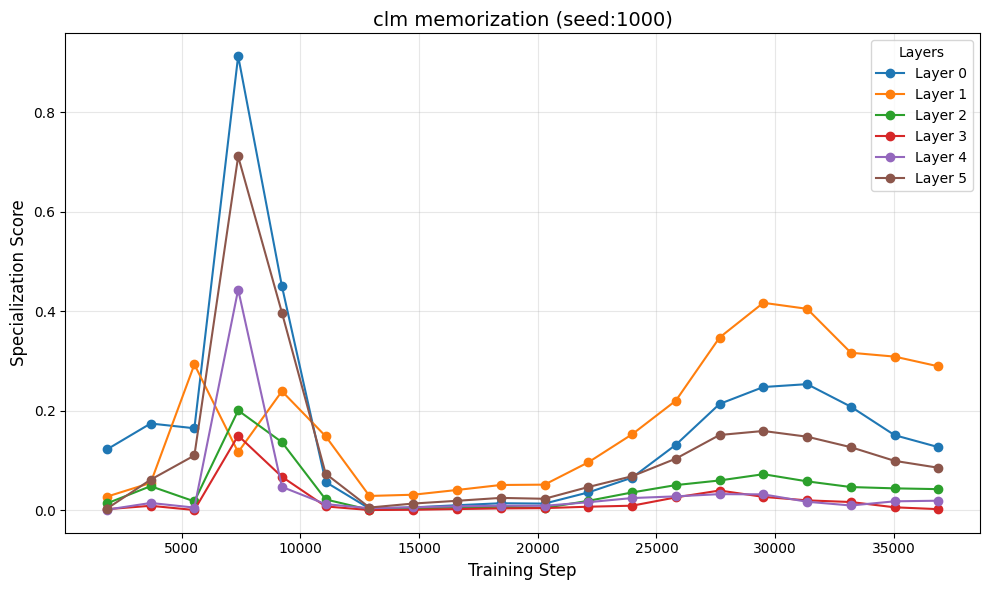

Selected layers for clustering: [1]


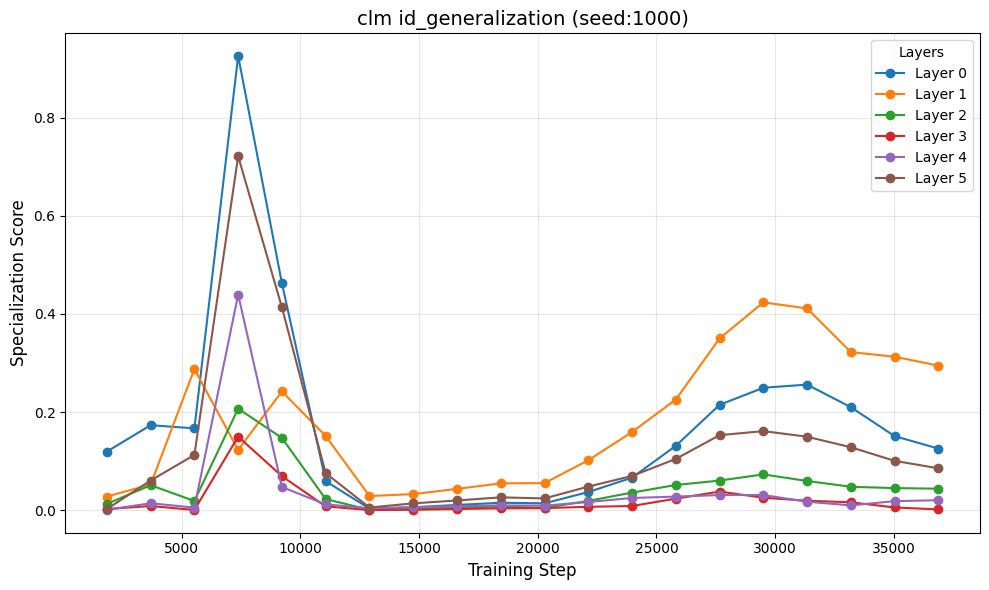

Selected layers for clustering: [1]


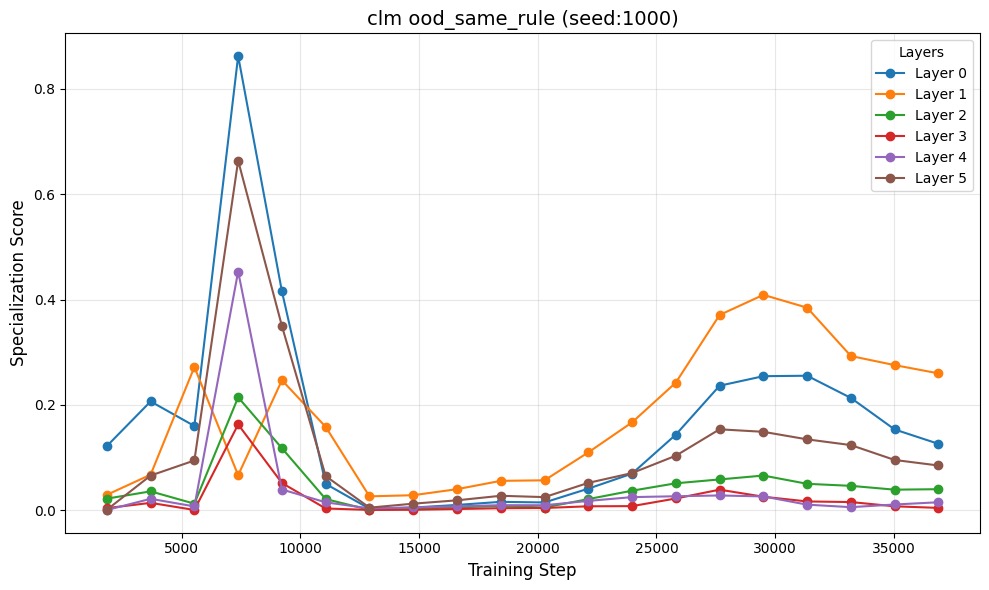

Selected layers for clustering: [0]


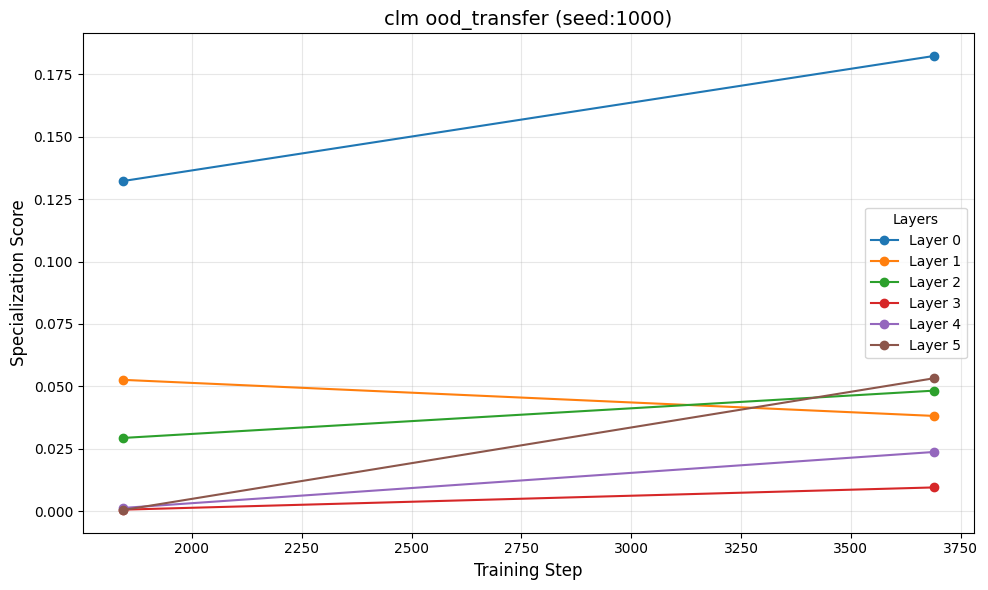

Selected layers for clustering: [2]


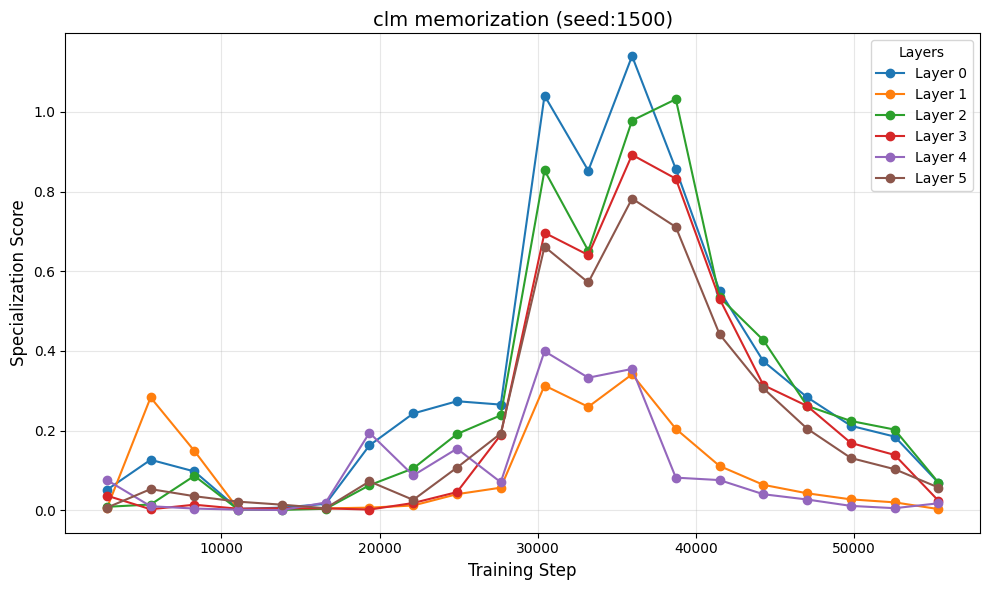

Selected layers for clustering: [2]


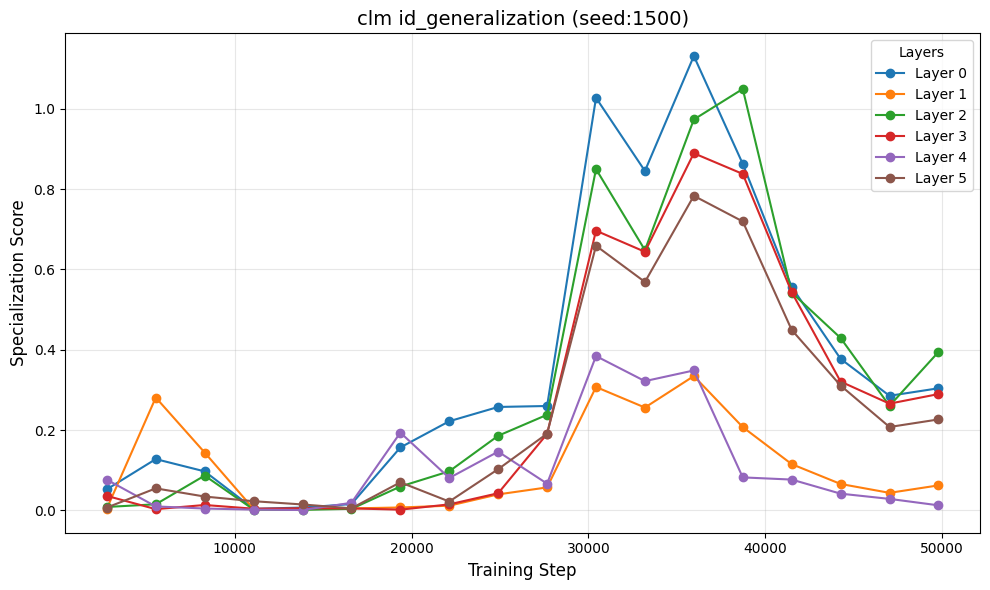

In [226]:
# Run pipeline first
prefix = Path("/Users/jliu/workspace/ICL/interp")
suffix = "noshuffle_seedbalanced/layer"
model_type = "clm"
seed_lst = [500, 1000, 1500]
eval_type_lst = ["memorization", "id_generalization", "ood_same_rule", "ood_transfer"]
spec_dict = {}
for seed in seed_lst:
    data_root = prefix / f"uniform_{seed}_L3_M3"/f"{model_type}_{suffix}"
    spec_dict[seed] = {}
    for eval_type in eval_type_lst:
        try:
            data = run_pipeline(data_root,eval_type, n_clusters=2,plot=False)
            plot_train(data,seed,eval_type,model_type)
        except:
            pass

Selected layers for clustering: [5]


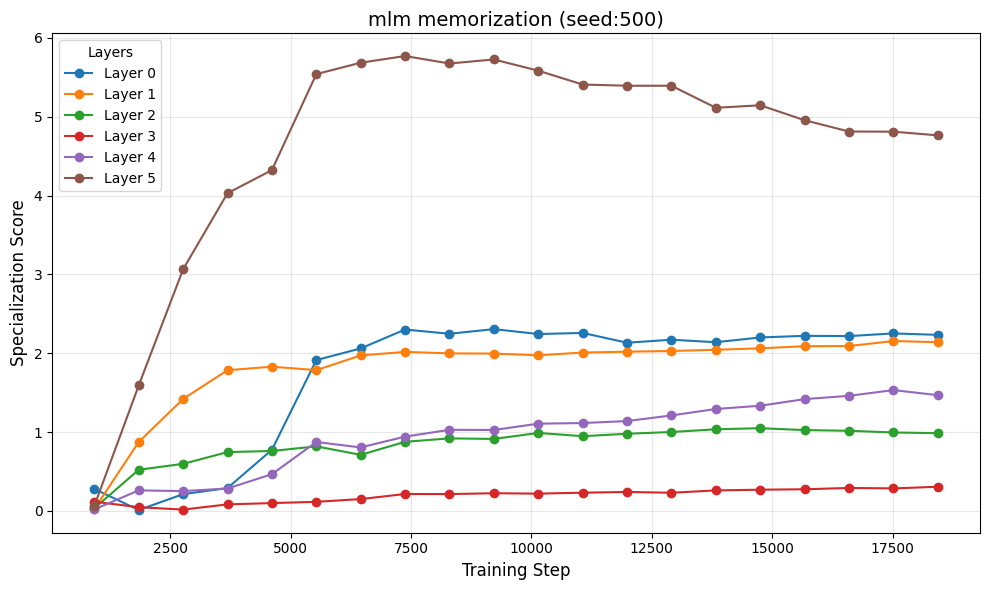

Selected layers for clustering: [5]


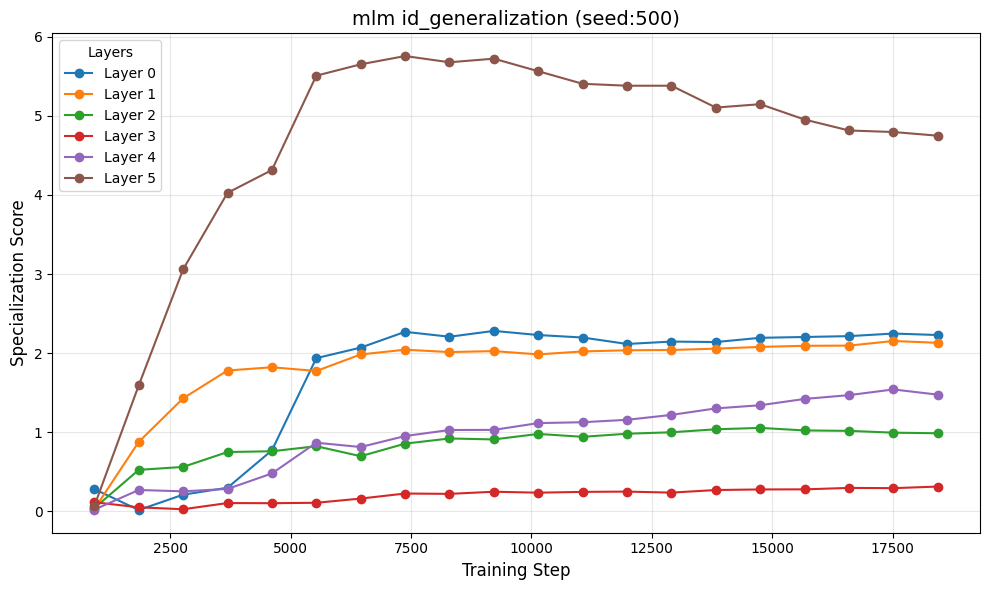

Selected layers for clustering: [5]


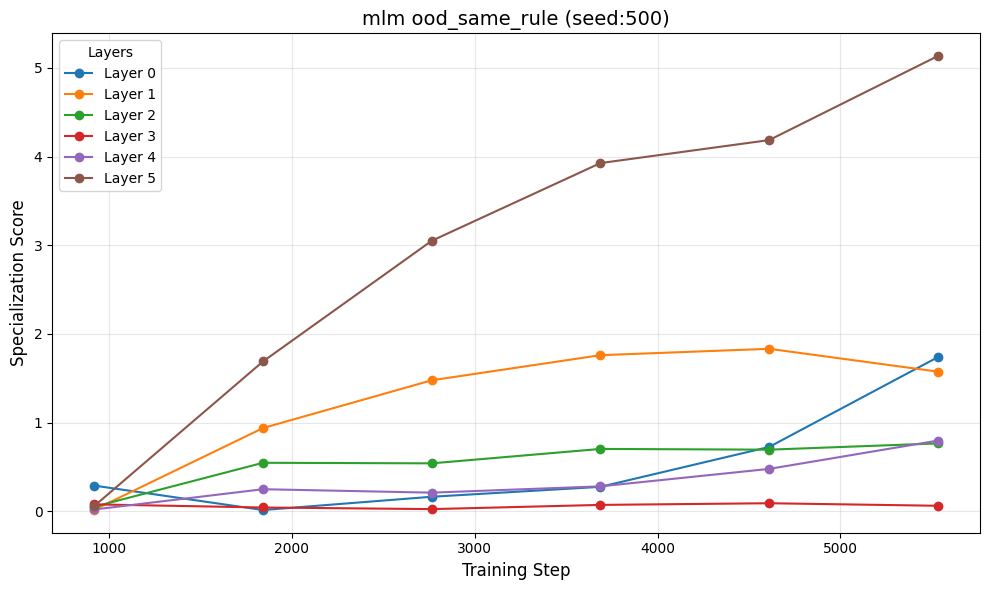

Selected layers for clustering: [5]


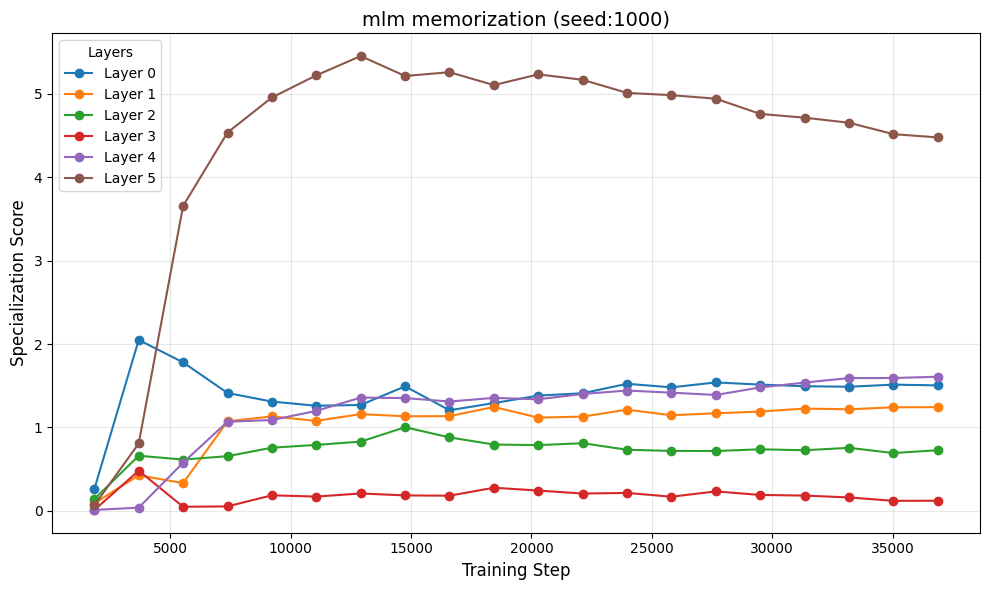

Selected layers for clustering: [5]


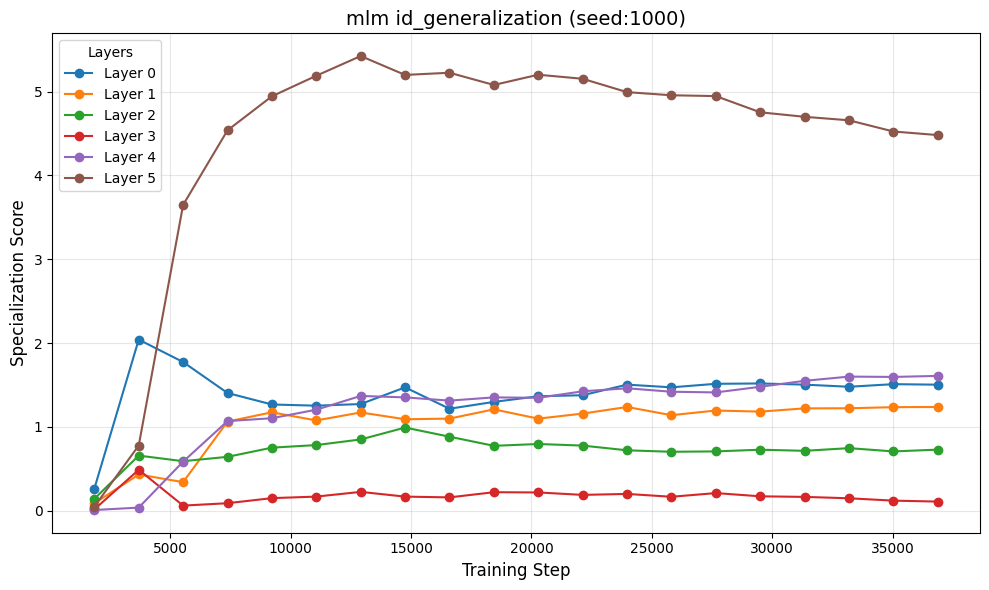

Selected layers for clustering: [5]


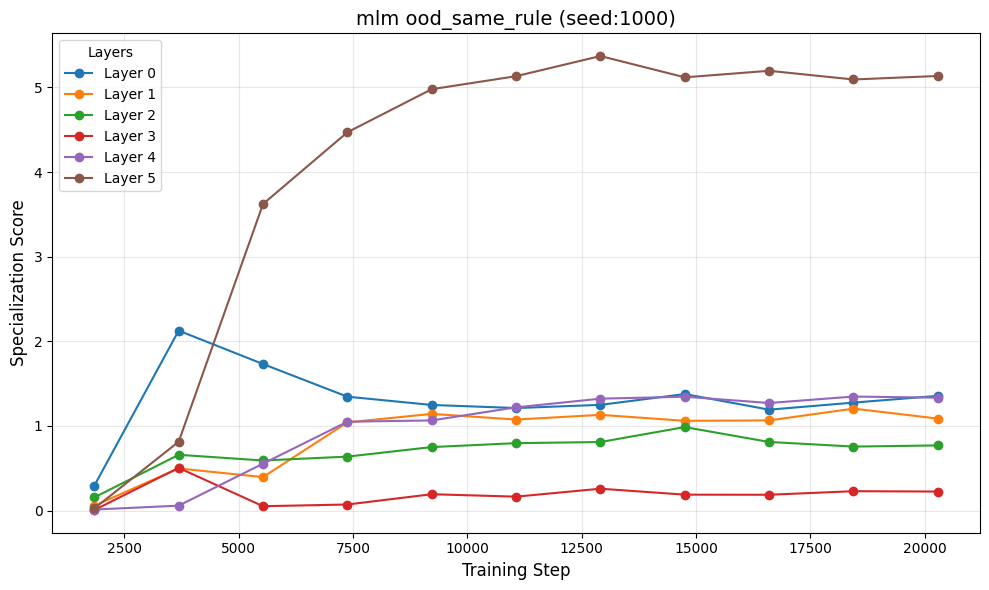

Selected layers for clustering: [5]


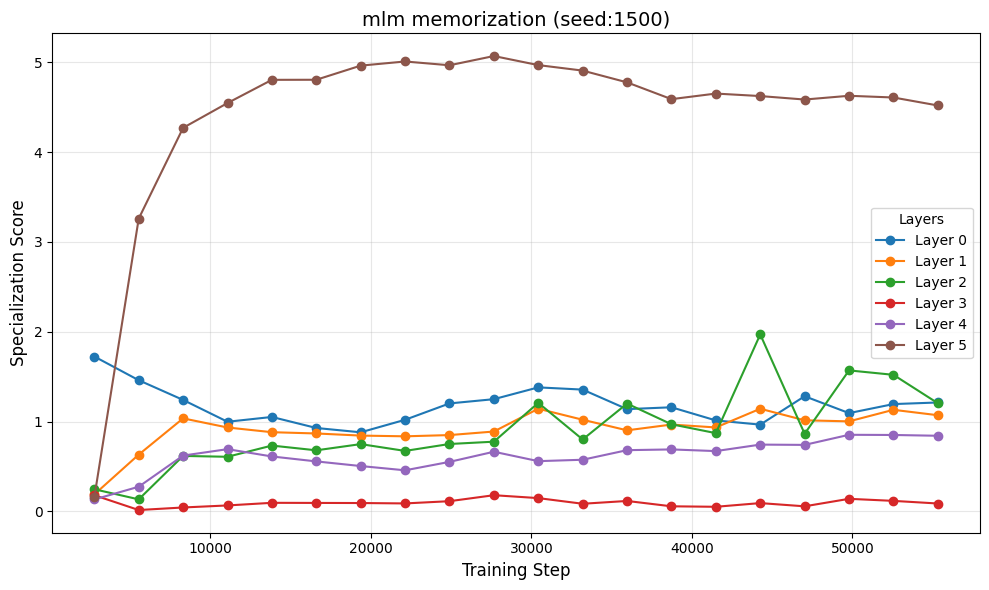

Selected layers for clustering: [5]


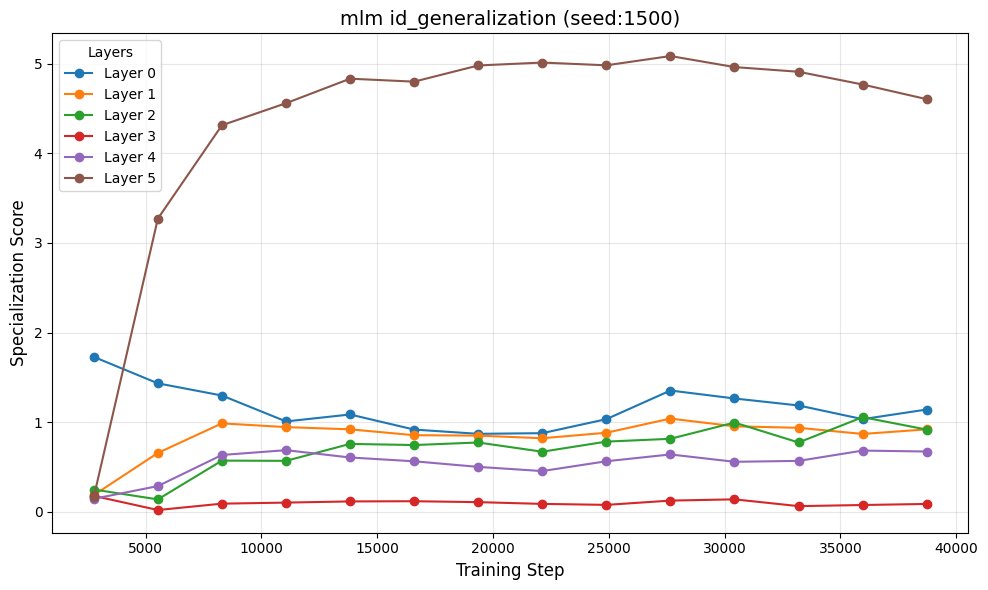

In [227]:
# Run pipeline first
prefix = Path("/Users/jliu/workspace/ICL/interp")
suffix = "noshuffle_seedbalanced/layer"
model_type = "mlm"
seed_lst = [500, 1000, 1500]
eval_type_lst = ["memorization", "id_generalization", "ood_same_rule", "ood_transfer"]
spec_dict = {}
for seed in seed_lst:
    data_root = prefix / f"uniform_{seed}_L3_M3"/f"{model_type}_{suffix}"
    spec_dict[seed] = {}
    for eval_type in eval_type_lst:
        try:
            data = run_pipeline(data_root,eval_type, n_clusters=2,plot=False)
            plot_train(data,seed,eval_type,model_type)
        except:
            pass

In [107]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ========================
# Phase-2: Geometry Analysis
# ========================

def extract_head_features_from_clustered(all_features, selected_layers):
    """
    Collect features and head mapping from Phase-1 for selected layers.

    Args:
        all_features (list[dict]): list of feature dicts from Phase-1
        selected_layers (list[int]): layers to include

    Returns:
        feature_matrix (np.array): N x D array of features (entropy, locality, cross_attention, query_to_context)
        head_map (list[tuple]): list of (seq_id, layer, head) mapping to rows
    """
    flattened_features = []
    head_map = []

    for f in all_features:
        layer = int(f["layer"])
        if layer not in selected_layers:
            continue
        feat_vec = [f["entropy"], f["locality"], f["cross_attention"], f["query_to_context"]]
        flattened_features.append(feat_vec)
        head_map.append((f["seq_id"], layer, f["head"]))

    feature_matrix = np.array(flattened_features)
    return feature_matrix, head_map


def run_pca(feature_matrix, n_components=2):
    """
    Reduce feature dimensionality using PCA.

    Args:
        feature_matrix (np.array): N x D feature matrix
        n_components (int): number of PCA components

    Returns:
        pca_features: N x n_components
        pca_model: fitted PCA object
    """
    pca_model = PCA(n_components=n_components)
    pca_features = pca_model.fit_transform(feature_matrix)
    return pca_features, pca_model


def scale_features(feature_matrix):
    """
    Standardize feature matrix to zero mean and unit variance.

    Args:
        feature_matrix (np.array): N x D

    Returns:
        scaled_features (np.array): N x D
        scaler (StandardScaler object)
    """
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(feature_matrix)
    return scaled_features, scaler


In [104]:
result_dict

{'selected_layers': [1, 0],
 'cluster_labels': {1: {0: 1, 1: 1, 2: 0, 3: 0, 4: 1, 5: 1, 6: 1, 7: 0},
  0: {0: 2, 1: 2, 2: 1, 3: 1, 4: 1, 5: 2, 6: 2, 7: 1}},
 'cluster_stats': {1: {0: {'num_heads': 3},
   1: {'num_heads': 5},
   2: {'num_heads': 0}},
  0: {0: {'num_heads': 0}, 1: {'num_heads': 4}, 2: {'num_heads': 4}}}}